# Fainter-fatter test: admom size & ellipticity of simulated stars vs magnitude

Recreates the upper (size `T`) and lower (`|e1|`, `|e2|`) panels of LITB III Fig. 9
with idealized simulations, to isolate a moment-estimator noise bias from any detector effect.

For each star in the SuperBIT detection catalog:
- star = `galsim.DeltaFunction(flux)` (flux from the catalog),
- convolved with a Gaussian PSF (fwhm 0.5) so any size trend is not from a real PSF,
- plus constant Gaussian noise `noise_sd = 12.719674` (same as the ShearNet configs),
- size `T` and ellipticity `e1, e2` measured with adaptive moments (`get_admoms`).

If `T` still rises toward faint magnitudes here (constant PSF, no detector model) the
"fainter-fatter" trend is a moment-based-estimator noise bias, not the detector.
(Refs: Refregier+ 2012, Melchior & Viola 2012.)

In [1]:
import numpy as np
import galsim
import matplotlib.pyplot as plt
from astropy.table import Table
from concurrent.futures import ProcessPoolExecutor

from shearnet.utils.superbit import get_admoms


def parallel_map(fn, n, workers, chunks_per_worker=8):
    if workers is None or workers <= 1:
        return [fn(i) for i in range(n)]
    chunk = max(1, n // (workers * chunks_per_worker))
    with ProcessPoolExecutor(max_workers=workers) as ex:
        return list(ex.map(fn, range(n), chunksize=chunk))

In [2]:
# config
CAT_PATH    = "/home/adfield/ShearNet/simulated_detection_truth_backcast_unit_fiducial_dec04.fits"
PSF_FWHM    = 0.5                # arcsec, Gaussian PSF
PIXEL_SCALE = 0.141              # arcsec / pixel
STAMP       = 53                 # pixels
HIGH_NOISE_SD    = 12.719674 * 6      # constant Gaussian noise
LOW_NOISE_SD     = 2.0
SEED        = 42
FLUX_SCALE  = 300 * 36 / 0.343   # crates_b -> electrons
MAG_ZP      = 29.146             # flux -> mag zeropoint
N_MAX       = 100000             # subsample cap for speed
N_BINS      = 20
WORKERS     = 8

# OPTIONAL
SUPERBIT_PSF_PATH    = "/home/adfield/SHEARNET_DATA/psfex-output/Abell3411_1_300_1684688714_clean_starcat.psf"

In [3]:
# star fluxes from the detection catalog
cat  = Table.read(CAT_PATH)
flux = np.asarray(cat["crates_b"], dtype=float) * FLUX_SCALE
flux = flux[np.isfinite(flux) & (flux > 0)]

rng = np.random.default_rng(SEED)
if len(flux) > N_MAX:
    flux = rng.choice(flux, N_MAX, replace=False)

mag = MAG_ZP - 2.5 * np.log10(flux)
print(f"{len(flux)} stars | flux [{flux.min():.1f}, {flux.max():.1f}] | "
      f"mag [{mag.min():.2f}, {mag.max():.2f}]")

89496 stars | flux [0.0, 1892298.4] | mag [13.45, 36.39]


In [4]:
# simulate each star and measure T, e1, e2 with adaptive moments
psf = galsim.Gaussian(fwhm=PSF_FWHM)

def measure_gauss(i):
    f    = flux[i]
    star = galsim.Convolve([galsim.DeltaFunction(flux=f), psf])
    im   = star.drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array
    # constant Gaussian noise, per-star seed
    im   = im + np.random.default_rng(SEED * 1_000_003 + i).normal(0.0, HIGH_NOISE_SD, im.shape)
    res  = get_admoms(im, PIXEL_SCALE, reduced=False)
    if res["flags"] == 0:
        return res["T"], res["e1"], res["e2"]
    return np.nan, np.nan, np.nan

def measure_gauss_lo(i):
    f    = flux[i]
    star = galsim.Convolve([galsim.DeltaFunction(flux=f), psf])
    im   = star.drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array
    im   = im + np.random.default_rng(SEED * 1_000_003 + i).normal(0.0, LOW_NOISE_SD, im.shape)
    res  = get_admoms(im, PIXEL_SCALE, reduced=False)
    if res["flags"] == 0:
        return res["T"], res["e1"], res["e2"]
    return np.nan, np.nan, np.nan

Tarr, e1arr, e2arr = (np.asarray(a) for a in zip(*parallel_map(measure_gauss, len(flux), WORKERS)))
Tarr_lo, e1arr_lo, e2arr_lo = (np.asarray(a) for a in zip(*parallel_map(measure_gauss_lo, len(flux), WORKERS)))

print(f"admom succeeded on {np.isfinite(Tarr).sum()} / {len(Tarr)} stars (high), "
      f"{np.isfinite(Tarr_lo).sum()} / {len(Tarr_lo)} (low)")

/home/adfield/.conda/envs/shearnet_all/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/adfield/.conda/envs/shearnet_all/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


admom succeeded on 86596 / 89496 stars (high), 89477 / 89496 (low)


In [5]:
# bin by magnitude (median + standard error)
def binned(x, y, n_bins):
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    idx = np.digitize(x, edges)
    cx, cy, ce = [], [], []
    for b in range(1, n_bins + 1):
        m = idx == b
        if m.sum() > 3:
            cx.append(np.median(x[m]))
            cy.append(np.median(y[m]))
            ce.append(np.std(y[m]) / np.sqrt(m.sum()))
    return np.array(cx), np.array(cy), np.array(ce)

mT,  T_med,  T_err  = binned(mag, Tarr,          N_BINS)
m1, e1_med, e1_err  = binned(mag, np.abs(e1arr), N_BINS)
m2, e2_med, e2_err  = binned(mag, np.abs(e2arr), N_BINS)

mT_lo,  T_med_lo,  T_err_lo  = binned(mag, Tarr_lo,          N_BINS)
m1_lo, e1_med_lo, e1_err_lo  = binned(mag, np.abs(e1arr_lo), N_BINS)
m2_lo, e2_med_lo, e2_err_lo  = binned(mag, np.abs(e2arr_lo), N_BINS)

Saved -> fainter_fatter_admom_test.png


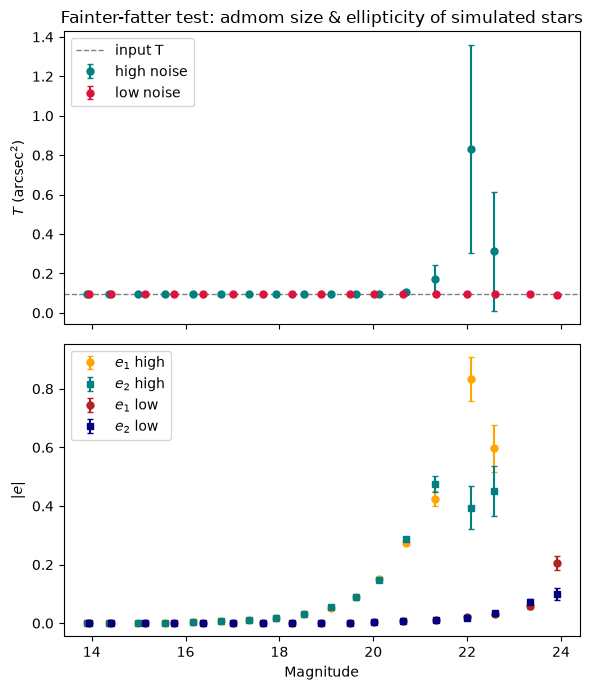

In [6]:
# plot: upper = T(mag), lower = |e1|,|e2|(mag)  (cf. Fig. 9)
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

ax0.errorbar(mT, T_med, yerr=T_err, fmt="o", color="teal", capsize=2, ms=5, label="high noise")
ax0.errorbar(mT_lo, T_med_lo, yerr=T_err_lo, fmt="o", color="crimson", capsize=2, ms=5, label="low noise")
ax0.set_ylabel(r"$T$ (arcsec$^2$)")
ax0.set_title("Fainter-fatter test: admom size & ellipticity of simulated stars")
T_input = get_admoms(
    galsim.Convolve([galsim.DeltaFunction(flux=1.0), psf])
          .drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array,
    PIXEL_SCALE, reduced=False)["T"]
ax0.axhline(T_input, color="gray", ls="--", lw=1, label="input T")
ax0.legend()

ax1.errorbar(m1, e1_med, yerr=e1_err, fmt="o", color="orange", capsize=2, ms=5, label=r"$e_1$ high")
ax1.errorbar(m2, e2_med, yerr=e2_err, fmt="s", color="teal",   capsize=2, ms=5, label=r"$e_2$ high")
ax1.errorbar(m1_lo, e1_med_lo, yerr=e1_err_lo, fmt="o", color="firebrick", capsize=2, ms=5, label=r"$e_1$ low")
ax1.errorbar(m2_lo, e2_med_lo, yerr=e2_err_lo, fmt="s", color="navy",      capsize=2, ms=5, label=r"$e_2$ low")
ax1.set_ylabel(r"$|e|$")
ax1.set_xlabel("Magnitude")
ax1.legend()

plt.tight_layout()
plt.savefig("fainter_fatter_admom_test.png", dpi=150, bbox_inches="tight")
print("Saved -> fainter_fatter_admom_test.png")

Everything is identical to the cells above (same catalog fluxes, same per-star
noise realization, same `get_admoms`, same magnitude binning) except the PSF: the
`galsim.Gaussian(fwhm=0.5)` is replaced by the real SuperBIT `DES_PSFEx` model,
sampled at a random field position per star. If the
`T`-vs-magnitude trend survives the swap, it is the moment estimator + noise, not
the PSF; if it changes, the PSF matters.

In [7]:
# simulate each star with the SuperBIT PSFEx PSF
import galsim.des
import shearnet.utils.superbit as sbutils

des_psf = galsim.des.DES_PSFEx(SUPERBIT_PSF_PATH, wcs=sbutils.get_galsim_tanwcs())
gsp     = galsim.GSParams(maximum_fft_size=32768)
IMG_XSIZE, IMG_YSIZE, MARGIN = 9600, 6400, 500

# sample the PSF from a single seed-dependent sky point, reused for every star
pos_rng = np.random.default_rng(SEED + 1)
x0 = int(pos_rng.integers(MARGIN, IMG_XSIZE - MARGIN))
y0 = int(pos_rng.integers(MARGIN, IMG_YSIZE - MARGIN))
psf_fixed = des_psf.getPSF(galsim.PositionD(x0, y0))

def measure_superbit(i):
    f     = flux[i]
    star  = galsim.Convolve([galsim.DeltaFunction(flux=f), psf_fixed], gsparams=gsp)
    im    = star.withGSParams(gsp).drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array
    im    = im + np.random.default_rng(SEED * 1_000_003 + i).normal(0.0, HIGH_NOISE_SD, im.shape)
    res   = get_admoms(im, PIXEL_SCALE, reduced=False)
    if res["flags"] == 0:
        return res["T"], res["e1"], res["e2"]
    return np.nan, np.nan, np.nan

def measure_superbit_lo(i):
    f     = flux[i]
    star  = galsim.Convolve([galsim.DeltaFunction(flux=f), psf_fixed], gsparams=gsp)
    im    = star.withGSParams(gsp).drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array
    im    = im + np.random.default_rng(SEED * 1_000_003 + i).normal(0.0, LOW_NOISE_SD, im.shape)
    res   = get_admoms(im, PIXEL_SCALE, reduced=False)
    if res["flags"] == 0:
        return res["T"], res["e1"], res["e2"]
    return np.nan, np.nan, np.nan

Tsb, e1sb, e2sb = (np.asarray(a) for a in zip(*parallel_map(measure_superbit, len(flux), WORKERS)))
Tsb_lo, e1sb_lo, e2sb_lo = (np.asarray(a) for a in zip(*parallel_map(measure_superbit_lo, len(flux), WORKERS)))

print(f"admom succeeded on {np.isfinite(Tsb).sum()} / {len(Tsb)} stars (high), "
      f"{np.isfinite(Tsb_lo).sum()} / {len(Tsb_lo)} (low) (SuperBIT PSF)")

/home/adfield/.conda/envs/shearnet_all/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/adfield/.conda/envs/shearnet_all/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


admom succeeded on 85844 / 89496 stars (high), 89476 / 89496 (low) (SuperBIT PSF)


In [8]:
# bin the SuperBIT-PSF results by magnitude (reuses binned() and mag)
mTs,  Ts_med,  Ts_err  = binned(mag, Tsb,          N_BINS)
m1s, e1s_med, e1s_err  = binned(mag, np.abs(e1sb), N_BINS)
m2s, e2s_med, e2s_err  = binned(mag, np.abs(e2sb), N_BINS)

mTs_lo,  Ts_med_lo,  Ts_err_lo  = binned(mag, Tsb_lo,          N_BINS)
m1s_lo, e1s_med_lo, e1s_err_lo  = binned(mag, np.abs(e1sb_lo), N_BINS)
m2s_lo, e2s_med_lo, e2s_err_lo  = binned(mag, np.abs(e2sb_lo), N_BINS)

Saved -> fainter_fatter_admom_test_superbit.png


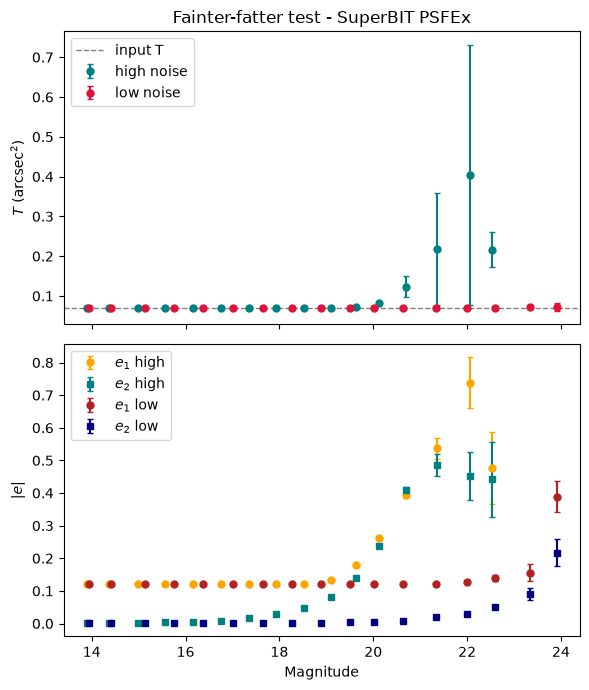

In [9]:
# plot: SuperBIT PSF version (cf. Fig. 9)
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

ax0.errorbar(mTs, Ts_med, yerr=Ts_err, fmt="o", color="teal", capsize=2, ms=5, label="high noise")
ax0.errorbar(mTs_lo, Ts_med_lo, yerr=Ts_err_lo, fmt="o", color="crimson", capsize=2, ms=5, label="low noise")
ax0.set_ylabel(r"$T$ (arcsec$^2$)")
ax0.set_title("Fainter-fatter test - SuperBIT PSFEx")
T_input = get_admoms(
    galsim.Convolve([galsim.DeltaFunction(flux=1.0), psf_fixed], gsparams=gsp)
          .drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array,
    PIXEL_SCALE, reduced=False)["T"]
ax0.axhline(T_input, color="gray", ls="--", lw=1, label="input T")
ax0.legend()

ax1.errorbar(m1s, e1s_med, yerr=e1s_err, fmt="o", color="orange", capsize=2, ms=5, label=r"$e_1$ high")
ax1.errorbar(m2s, e2s_med, yerr=e2s_err, fmt="s", color="teal",   capsize=2, ms=5, label=r"$e_2$ high")
ax1.errorbar(m1s_lo, e1s_med_lo, yerr=e1s_err_lo, fmt="o", color="firebrick", capsize=2, ms=5, label=r"$e_1$ low")
ax1.errorbar(m2s_lo, e2s_med_lo, yerr=e2s_err_lo, fmt="s", color="navy",      capsize=2, ms=5, label=r"$e_2$ low")
ax1.set_ylabel(r"$|e|$")
ax1.set_xlabel("Magnitude")
ax1.legend()

plt.tight_layout()
plt.savefig("fainter_fatter_admom_test_superbit.png", dpi=150, bbox_inches="tight")
print("Saved -> fainter_fatter_admom_test_superbit.png")

Saved -> fainter_fatter_gauss_vs_superbit.png


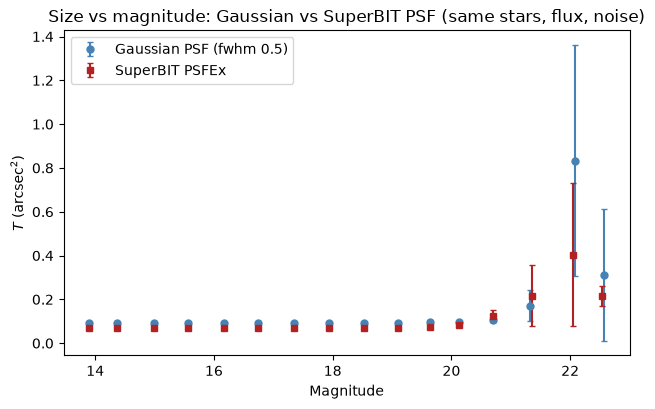

In [10]:
# direct comparison: T(mag) for Gaussian vs SuperBIT PSF
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(mT,  T_med,  yerr=T_err,  fmt="o", color="steelblue", capsize=2, ms=5,
            label="Gaussian PSF (fwhm 0.5)")
ax.errorbar(mTs, Ts_med, yerr=Ts_err, fmt="s", color="firebrick", capsize=2, ms=5,
            label="SuperBIT PSFEx")
ax.set_xlabel("Magnitude")
ax.set_ylabel(r"$T$ (arcsec$^2$)")
ax.set_title("Size vs magnitude: Gaussian vs SuperBIT PSF (same stars, flux, noise)")
ax.legend()
plt.tight_layout()
plt.savefig("fainter_fatter_gauss_vs_superbit.png", dpi=150, bbox_inches="tight")
print("Saved -> fainter_fatter_gauss_vs_superbit.png")